In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("clv_data.csv")

# Keep only numerical columns
df = df.select_dtypes(include=[np.number])

# Drop rows with all NaNs (rare but safe)
df = df.dropna(how='all')

print(df.shape)
df.head()

(5000, 6)


,Unnamed: 0,id,age,income,days_on_platform,purchases
0,0,0,NaN,126895,14.0,0
1,1,1,NaN,161474,14.0,0
2,2,2,24.0,104723,34.0,1
3,3,3,29.0,43791,28.0,2
4,4,4,18.0,132181,26.0,2


In [20]:
# Fill missing values temporarily to create ground truth
imputer_full = SimpleImputer(strategy="mean")
df_full = pd.DataFrame(imputer_full.fit_transform(df), columns=df.columns)

# Convert to numpy
X_full = df_full.values

In [21]:
def create_mask(data, missing_ratio=0.2):
    mask = np.random.rand(*data.shape) < missing_ratio
    return mask.astype(int)

mask = create_mask(X_full, missing_ratio=0.2)

# Create corrupted input
X_corrupted = X_full.copy()
X_corrupted[mask == 1] = np.nan

In [22]:
imputer = SimpleImputer(strategy="mean")
X_input = imputer.fit_transform(X_corrupted)

In [23]:
X_train, X_test, mask_train, mask_test, full_train, full_test = train_test_split(
    X_input, mask, X_full, test_size=0.2, random_state=42
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Scale ground truth also (IMPORTANT)
full_train = scaler.transform(full_train)
full_test = scaler.transform(full_test)

In [25]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation="relu")(input_layer)
x = Dropout(0.2)(x)
x = Dense(64, activation="relu")(x)

# Bottleneck
bottleneck = Dense(32, activation="relu")(x)

# Decoder
x = Dense(64, activation="relu")(bottleneck)
x = Dense(128, activation="relu")(x)

output_layer = Dense(input_dim, activation="linear")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,438 (87.65 KB)

 Trainable params: 22,438 (87.65 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train,
    full_train,   # learn to reconstruct TRUE values
    epochs=50,
    batch_size=32,
    validation_data=(X_test, full_test),
    verbose=1
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 50ms/step - loss: 0.8971 - val_loss: 0.2212
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2411 - val_loss: 0.2125
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.2273 - val_loss: 0.2045
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.2312 - val_loss: 0.2023
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.2230 - val_loss: 0.2019
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.2136 - val_loss: 0.1994
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.2150 - val_loss: 0.1989
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.2143 - val_loss: 0.1947
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.1992 - val_loss: 0.1934
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.2086 - val_loss: 0.1931
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.2027 - val_loss: 0.1907
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━

In [27]:
X_test_pred = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step


In [28]:
X_test_imputed = X_test.copy()

X_test_imputed[mask_test == 1] = X_test_pred[mask_test == 1]

In [29]:
diff = full_test[mask_test == 1] - X_test_imputed[mask_test == 1]

mse = np.mean(diff ** 2)

print("Imputation MSE:", mse)

Imputation MSE: 0.8958968632936751


In [30]:
baseline_imputer = SimpleImputer(strategy="mean")

baseline = baseline_imputer.fit_transform(X_corrupted)
baseline_test = baseline[-len(full_test):]

baseline_test = scaler.transform(baseline_test)

baseline_mse = np.mean(
    (full_test[mask_test == 1] - baseline_test[mask_test == 1]) ** 2
)

print("Baseline MSE:", baseline_mse)

Baseline MSE: 2.515267544024875


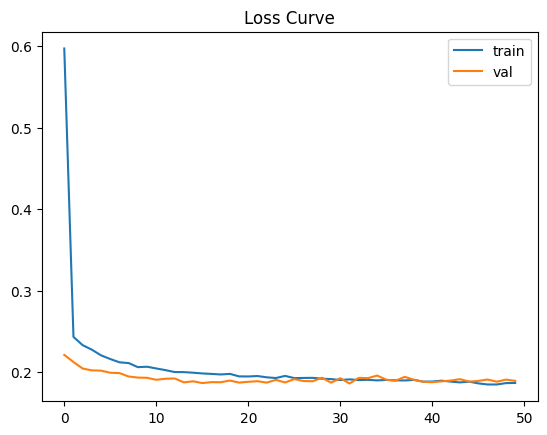

In [31]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()